In [1]:
# %% Import most relevant packages and definitions
import DBW.udkm1Dsim as ud

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [2]:
u = ud.u  # import the pint unit registry from udkm1Dsim
u.setup_matplotlib()  # use matplotlib with pint units

u.ang = 1e-10 *u.m
u.gm = 1e-3 * u.kg

forceRecalc = True
cache_dir='cache'

In [3]:
# %% Set simulation parameters
T_start = 450
heatDiffusion = True
only_heat_var = True

F = 5

In [4]:
# %% Introduce necessary elements from database
Mg = ud.Atom('Mg')
O  = ud.Atom('O')
Pt = ud.Atom('Pt')

In [5]:
# %% Platinum
prop_Pt = {}
prop_Pt['heat_capacity'] = ['lambda T: 740/21450*T',
                            'lambda T: (23.8992 +7.89939e-3*T -3.77463e-6*T**2 +1.53451e-9*T**3 -27697.5/(T**2))/(195.084/1000.0)'] # J. W. Arblaster 2005
prop_Pt['therm_cond'] = ['lambda T: (71-5)*(T[0]/T[1])',
                         5 * u.W/(u.m * u.K)]
prop_Pt['sub_system_coupling'] = ['lambda T: -0.5* (-7.09e-3*T[0]**5 +3.64e2*T[0]**4  -7.30e6*T[0]**3   +7.29e10*T[0]**2 -3.85e14*T[0] + 12.046e17)*(T[0]-T[1])',
                                  'lambda T:  0.5* (-7.09e-3*T[0]**5 +3.64e2*T[0]**4  -7.30e6*T[0]**3   +7.29e10*T[0]**2 -3.85e14*T[0] + 12.046e17)*(T[0]-T[1])'] 
prop_Pt['lin_therm_exp'] = ['lambda T: 2.22e-9*T',
                            'lambda T: (1.300e-13*T**5 + -4.176e-10*T**4 + 5.179e-07*T**3 + -3.088e-04*T**2 + 9.093e-02*T + 9.343e+00)*1e-6 - 2.22e-9*T']
prop_Pt['sound_vel'] = 3.95 *u.nm/u.ps #4.242
prop_Pt['opt_ref_index'] =  2.55 + 6.35j#1030nm Rössle

c_Pt = 0.22649 * u.nm
# calculate so that density of unit cell is the density of Pt -> the simulation uses the mass per unit cell.
prop_Pt['a_axis'] = c_Pt
prop_Pt['b_axis'] = c_Pt / 0.77 

prop_Pt['deb_wal_Bfac'] = ['0','0.02938 + 0.1090e-2*T + 0.4310e-6*(T**2) - 0.4681e-9*(T**3) + 0.1829e-12*(T**4)'] #peng gao
prop_Pt['deb_wal_fac'] = ['0','sqrt(1*( (0.02938 + 0.1090e-2*T + 0.4310e-6*(T**2) - 0.4681e-9*(T**3) + 0.1829e-12*(T**4)))/(8*pi**2))*1E-10']


layer_Pt = ud.UnitCell('Pt', 'Platinum', c_Pt, **prop_Pt)
layer_Pt.add_atom(Pt, 0)


Number of subsystems changed from 1 to 2.


In [6]:
# %% MgO layer
prop_MgO = {}
prop_MgO['heat_capacity'] = [0.00001, 877]
#prop_MgO['therm_cond'] = [0, 50/3] 
prop_MgO['therm_cond'] = [0,'lambda T: 2.42e4 * (T**-1.114) /1.25'] #from [J. Res. Natl. Inst. Stand. Technol. 103, 357 (1998)
prop_MgO['sub_system_coupling'] = ['lambda T:-1.0e17*(T[0]-T[1])', 'lambda T: 1.0e17*(T[0]-T[1])']
prop_MgO['lin_therm_exp'] = [0,'lambda T: 1.61*(1.664e-13*T**5 + -5.689e-10*T**4 + 7.591e-07*T**3 + -4.935e-04*T**2 + 1.633e-01*T + -1.033e+01)*1e-6']
prop_MgO['sound_vel'] = 9.12  *u.nm/u.ps
prop_MgO['opt_ref_index'] = 1.7222
prop_MgO['deb_wal_fac'] = ['0','0']

cMgO           = 0.421272 * u.nm
# calculate so that density of unit cell is the density of MgO -> the simulation uses the mass per unit cell.
#prop_MgO['a_axis'] = 0.08874*u.nm
#prop_MgO['b_axis'] = 1*u.nm

layer_MgO = ud.UnitCell('MgO', 'MgO', cMgO, **prop_MgO)
layer_MgO.add_atom(Mg, 0)
layer_MgO.add_atom(O, 0)
layer_MgO.add_atom(Mg, 0)
layer_MgO.add_atom(O, 0)
layer_MgO.add_atom(Mg, 0.5)
layer_MgO.add_atom(O, 0.5)
layer_MgO.add_atom(Mg, 0.5)
layer_MgO.add_atom(O, 0.5)

Number of subsystems changed from 1 to 2.


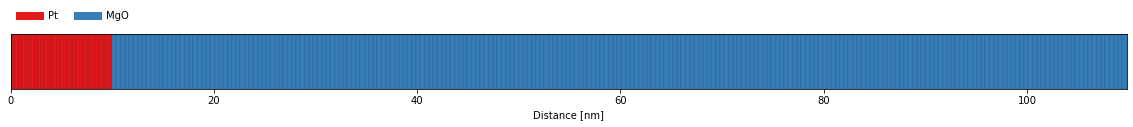

Structure properties:

Name   : 16nm Pt
Thickness : 109.81 nanometer
Roughness : 0.00 nanometer
----
44 times Platinum: 9.97 nanometer
237 times MgO: 99.84 nanometer
----
no substrate



In [7]:
# %% Build Sample structure
S = ud.Structure('16nm Pt')

S.add_sub_structure(layer_Pt, np.int_(np.round(10*u.nm/c_Pt)))
S.add_sub_structure(layer_MgO, np.int_(np.round(100*u.nm/cMgO))) #only heat

S.visualize()
print(S)

In [8]:
# %% Define the simulation grid in time and space
part1 = np.arange(-10, -1, 3)
part2 = np.arange(-1, 5, 0.25)

num_points = 50 
part4 = np.logspace(np.log10(5), np.log10(500), num=num_points)

delay_axis = np.concatenate([part1, part2, part4])
print("Total points:", len(delay_axis))

delays = delay_axis*u.ps
_, _, distances = S.get_distances_of_layers()

Total points: 77


In [9]:
# %% Initialize the heat simulation and set excitation conditions
H = ud.Heat(S, forceRecalc, cache_dir=cache_dir) #S, force recalc
H.excitation = {'fluence':     [F]*u.mJ/u.cm**2,
                'delay_pump':  [0.]*u.ps,
                'pulse_width': [600]*u.fs,
                'multilayer_absorption': True,
                'wavelength': 1030*u.nm,
                'theta': 55*u.deg}

In [10]:
H.save_data = True
H.disp_messages = True

# enable heat diffusion
H.heat_diffusion = heatDiffusion

# set the boundary conditions
H.boundary_conditions = {'top_type': 'isolator', 'bottom_type': 'temperature', 'bottom_value': [T_start,T_start]*u.K}

# The resulting temperature profile is calculated in one line:
init_temp = np.zeros([S.get_number_of_layers(), 2])
init_temp[:, 0] = T_start * np.ones(S.get_number_of_layers())

Absorption profile is calculated by multilayer formalism.
Total reflectivity of 38.6 % and transmission of 28.8 %.


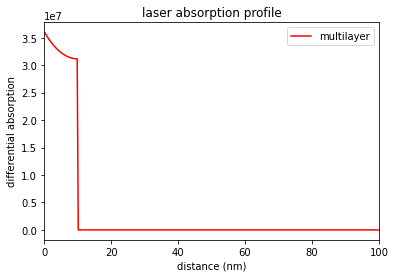

In [11]:
# %% Model initial Excitation profile
plt.figure()
dAdz, _, _, _ = H.get_multilayers_absorption_profile()
plt.plot(distances.to('nm'), dAdz, '-r', label='multilayer')
plt.legend()
plt.xlabel('distance (nm)')
plt.ylabel('differential absorption')
plt.title('laser absorption profile')
plt.xlim([0, 100])

plt.show()

In [12]:
# %% Actual Heat simulation takes place here
temp_map, delta_temp = H.get_temp_map(delays, T_start)

Surface incidence fluence scaled by factor 0.8192 due to incidence angle theta=55.00 deg
Calculating _heat_diffusion_ without excitation...


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_: 3.513860 s
Calculating _heat_diffusion_ for excitation 1:1 ...
Absorption profile is calculated by multilayer formalism.
Total reflectivity of 38.6 % and transmission of 28.8 %.


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_ with 1 excitation(s): 11.443237 s
Calculating _heat_diffusion_ without excitation...


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_: 25.460455 s
Elapsed time for _temp_map_: 40.525348 s
_temp_map_ saved to file:
	 temp_map_5b086fcff48fe955612553a59376bd6b_1f0d033370eb4e79d09a6292c1cea976.npz


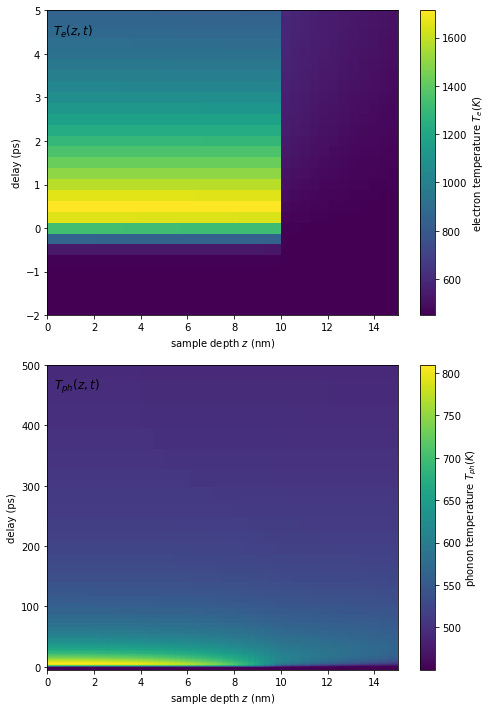

In [13]:
plt.figure(figsize=[7, 10])
plt.subplot(2, 1, 1)
plt.pcolormesh(distances.to('nm').magnitude, delays.to('ps').magnitude, temp_map[:, :, 0])
cbar = plt.colorbar()
cbar.set_label('electron temperature $T_{e} (K)$')
plt.ylim([-2, 5])
plt.xlim([0, 15])
plt.xlabel('sample depth $z$ (nm)')
plt.ylabel('delay (ps)')
plt.title('$T_{e}(z,t)$', y=0.9, x=0.075)

plt.subplot(2, 1, 2)
plt.pcolormesh(distances.to('nm').magnitude, delays.to('ps').magnitude, temp_map[:, :, 1]+0.001)
cbar = plt.colorbar()
cbar.set_label('phonon temperature $T_{ph} (K)$')
plt.ylim([-5, 500])
plt.xlim([0, 15])
plt.xlabel('sample depth $z$ (nm)')
plt.ylabel('delay (ps)')
plt.title('$T_{ph}(z,t)$', y=0.9, x=0.085)

plt.tight_layout()

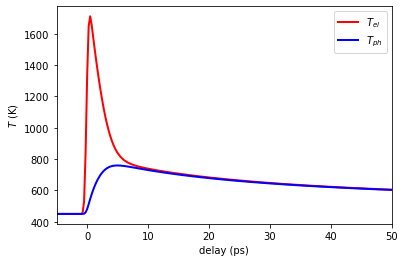

In [14]:
select_Pt= S.get_all_positions_per_unique_layer()['Pt']
T_el_Au = np.mean(temp_map[:, select_Pt, 0], 1)
T_ph_Au = np.mean(temp_map[:, select_Pt, 1], 1)

plt.figure()
plt.plot(delays.to('ps').magnitude, T_el_Au, color="red", label="$T_{el}$", lw=2)
plt.plot(delays.to('ps').magnitude, T_ph_Au, color="blue", label="$T_{ph}$", lw=2)
plt.xlim([-5,50])
plt.xlabel('delay (ps)')
plt.ylabel(r'$T$ (K)')
plt.legend();

In [15]:
# %% Strain calculation using phonon numerics class
Pnum = ud.PhononNum(S, forceRecalc, only_heat=only_heat_var, cache_dir=cache_dir)
Pnum.save_data = True
Pnum.disp_messages = True

strain_map = Pnum.get_strain_map(delays, temp_map, delta_temp)

Calculating linear thermal expansion ...
Elapsed time for _strain_map_: 0.045554 s
_strain_map_num_ saved to file:
	 strain_map_num_ccb27c2eaca2580c83d0289ddfb966bd_ecd1fc9a7fbd87f5ef8a5ef850e14e64.npz


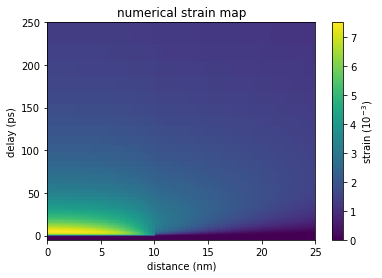

In [16]:
# %% Plot Strain Map  and layer averaged strains

plt.figure()
plt.pcolormesh(distances.to('nm').magnitude, delays.to('ps').magnitude,1E3*strain_map, shading='auto')
cbar = plt.colorbar()
cbar.set_label('strain ($10^{-3}$)')
plt.ylim([-5, 250])
plt.xlim([0, 25])
plt.xlabel('distance (nm)')
plt.ylabel('delay (ps)')
plt.title('numerical strain map')
plt.show()

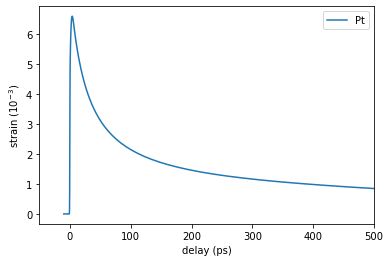

In [17]:
plt.figure()
plt.plot(delays.to('ps').magnitude, 1e3*np.mean(strain_map[:, select_Pt], 1), label="Pt")
plt.ylabel('strain ($10^{-3}$)')
plt.xlabel('delay (ps)')
plt.xlim([-50, 500])
plt.legend()
plt.show()

In [18]:
# %% x-ray scattering
dyn = ud.XrayDynDebyeWaller(S, forceRecalc)
dyn.disp_messages = True
dyn.save_data = False

incoming polarizations set to: sigma
analyzer polarizations set to: unpolarized


Calculating _homogenous_reflectivity_ ...
Elapsed time for _homogenous_reflectivity_: 0.026936 s


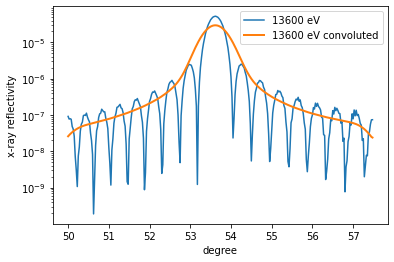

In [19]:
# %% Homogeneous X-ray scattering
order=4
dyn.energy = np.r_[3400*order]*u.eV  # set photon energie
dyn.theta = 1*np.r_[50:57.5:0.025]*u.degree  # set theta range

R_hom, A = dyn.homogeneous_reflectivity()

#instrument function / mosaicity of sample
FWHM = order * 0.02/1e-10  # Angstrom
sigma = FWHM/2.3548

def handle(x): return np.exp(-((x)/sigma)**2/2)
y_conv = dyn.conv_with_function(R_hom[0, :], dyn._qz[0, :], handle)

plt.figure()
plt.semilogy(dyn.theta[0, :]/1, R_hom[0, :], label='{}'.format(dyn.energy[0]))
plt.semilogy(dyn.theta[0, :], y_conv, label='{} convoluted'.format(dyn.energy[0]), lw=2)
plt.ylabel('x-ray reflectivity')
#plt.xlabel(r'$q_z$ ($\mathrm{\AA}^{-1}$)')
plt.legend()
plt.show()


In [20]:
# %% Inhomogeneous X-ray scattering
parallel = True

if parallel:
    from dask.distributed import Client
    client = Client()
    R_seq = dyn.inhomogeneous_reflectivity(strain_map, temp_map, calc_type='parallel', dask_client=client)
    client.close()
else:
    R_seq = dyn.inhomogeneous_reflectivity(strain_map, temp_map, calc_type='sequential')

R_seq_conv = np.zeros_like(R_seq)
for i, delay in enumerate(delays):
    R_seq_conv[i, 0, :] = dyn.conv_with_function(
        R_seq[i, 0, :], dyn._qz[0, :], handle)

Calculating _inhomogeneousReflectivity_ ...
Elapsed time for _inhomogeneous_reflectivity_: 53.272936 s


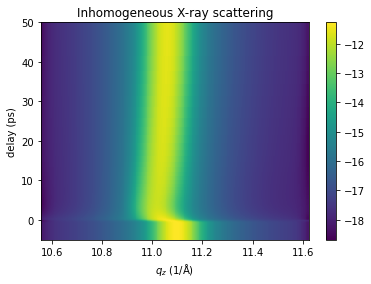

In [21]:
# %% Plot Strain Map  and layer averaged strains
plt.figure()
plt.pcolormesh(dyn._qz[0, :]*1E-10, delays.to('ps').magnitude, np.log(R_seq_conv[:, 0, :]))
plt.colorbar()
plt.ylim([-5, 50])
plt.xlabel('$q_z$ (1/Å)')
plt.ylabel('delay (ps)')
plt.title('Inhomogeneous X-ray scattering')
plt.show()

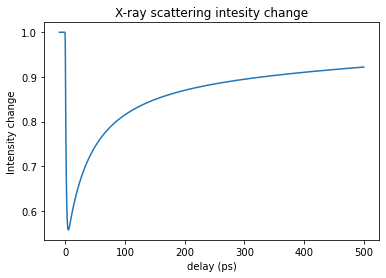

In [22]:
plt.figure()
plt.plot(delays.to('ps').magnitude, np.sum(R_seq_conv[:, 0, :],axis=1)/np.sum(R_seq_conv[0, 0, :]));
plt.title('X-ray scattering intesity change');
plt.ylabel('Intensity change');
plt.xlabel('delay (ps)');

## 